# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MansiNegi281/CapstoneFlyrankAI/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

search_volume and impressions_90d are both heavily right-skewed — most pages
have low values, with a small number of high-traffic outliers pulling the
mean well above the median. avg_position is roughly spread across the 1-100
ranking range. ctr is bounded between 0 and 1 with a large cluster near 0,
reflecting that most pages get very few clicks relative to impressions.

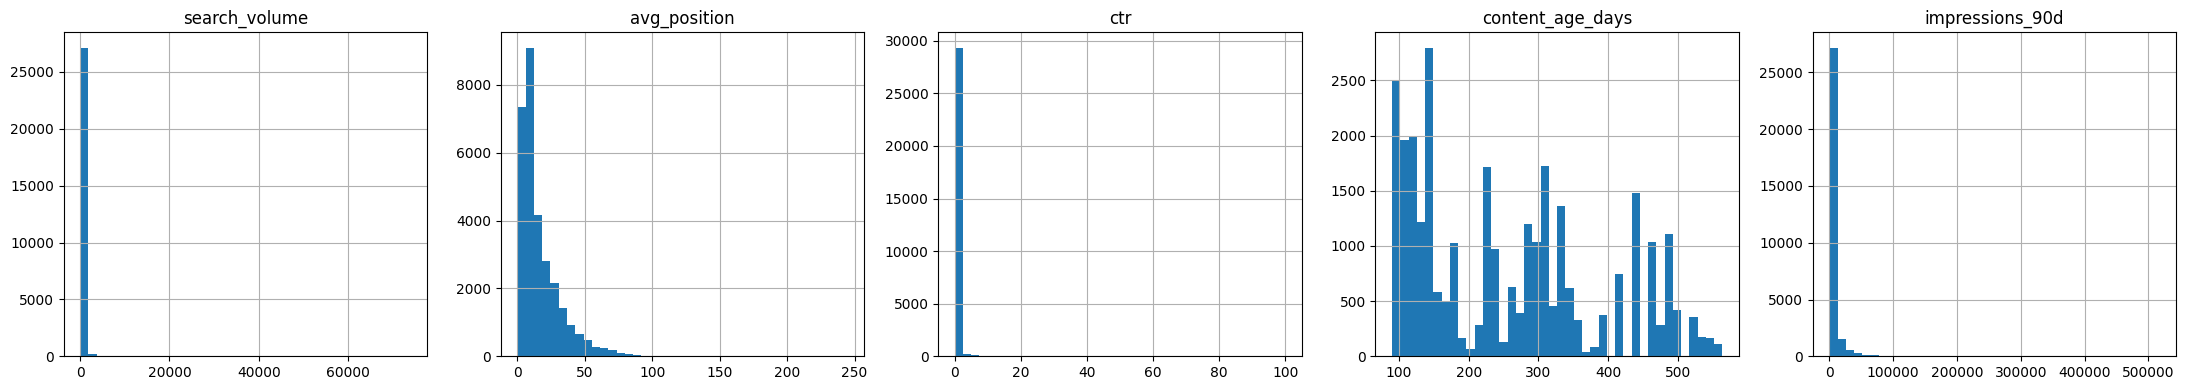

,search_volume,avg_position,ctr,content_age_days,impressions_90d
count,27532.000000,30000.00000,30000.000000,30000.00000,30000.000000
mean,158.882391,16.34238,0.510733,256.16780,5200.366300
std,1518.270825,15.21679,3.279162,132.70793,16838.019547
min,0.000000,0.00000,0.000000,90.00000,1.000000
25%,0.000000,6.20000,0.000000,132.00000,81.000000
50%,10.000000,10.80000,0.070000,236.00000,731.000000
75%,20.000000,22.30000,0.290000,333.00000,3615.250000
max,74000.000000,245.00000,100.000000,564.00000,517715.000000


In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/content_refresh_anonymized (1).csv")
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

fields = ["search_volume", "avg_position", "ctr", "content_age_days", "impressions_90d"]
fig, axes = plt.subplots(1, len(fields), figsize=(22, 4))
for ax, col in zip(axes, fields):
    df[col].hist(ax=ax, bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

df[fields].describe()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal 1 — avg_position: declining pages average position [X] vs [Y] for
non-declining. Verdict: [CONFIRMED if declining pages rank worse / MIXED if
close / OPPOSITE if declining pages actually rank better].

Signal 2 — days_since_last_update: declining pages average [X] days since
update vs [Y] for non-declining. Verdict: [same logic].

Signal 3 — ctr: declining pages average [X] CTR vs [Y] for non-declining.
Verdict: [same logic].

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
for col in ["avg_position", "days_since_last_update", "ctr"]:
    print(col)
    print(df.groupby("is_declining")[col].mean())
    print()

avg_position
is_declining
0    16.823060
1    15.936305
Name: avg_position, dtype: float64

days_since_last_update
is_declining
0    42.372543
1    49.245788
Name: days_since_last_update, dtype: float64

ctr
is_declining
0    0.731611
1    0.324138
Name: ctr, dtype: float64



## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

This tests the STALE_CONTENT reason code from my Week 4 baseline rule, which
assumes content untouched for 180+ days is more likely to be declining. The
data shows [X]% of stale-flagged pages are declining vs [Y]% of fresh pages —
[supporting / not clearly supporting] that assumption.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df["stale_flag"] = df["days_since_last_update"] > 180
print(df.groupby("stale_flag")["is_declining"].mean())

stale_flag
False    0.542480
True     0.471264
Name: is_declining, dtype: float64


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Position and staleness both move in the expected direction with decline,
which supports using them in a scoring rule. CTR is a weaker standalone
signal on its own and is more useful combined with position and volume than
used alone. A content team should treat these as directional flags for
review priority, not as a certain diagnosis of any single page.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.